---
## Task 1. Loading Data

### Task 1.1 Importing the pandas library


In [1]:
import pandas as pd

### Task 1.2 Reading Data
Read and save three CSV files into separate dataframes. Name the dataframes according to the file names, adding the prefix `df_`, for example, `df_users_go`. To access the files, use the following links:

- https://code.s3.yandex.net/datasets/users_go.csv
- https://code.s3.yandex.net/datasets/rides_go.csv
- https://code.s3.yandex.net/datasets/subscriptions_go.csv

In [2]:
df_users_go = pd.read_csv('https://code.s3.yandex.net/datasets/users_go.csv')
df_rides_go = pd.read_csv('https://code.s3.yandex.net/datasets/rides_go.csv')
df_subscriptions_go = pd.read_csv('https://code.s3.yandex.net/datasets/subscriptions_go.csv') 

### Task 1.3 Print First Rows


In [3]:
# Table df_users_go

display(df_users_go.head())

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra


In [4]:
# Table df_rides_go

display(df_rides_go.head())

,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28


In [5]:
# Table df_subscriptions_go

display(df_subscriptions_go.head())

,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


### Task 1.4 Row Count


In [6]:
print(f"{df_users_go.shape[0]} {df_rides_go.shape[0]} {df_subscriptions_go.shape[0]}")

1565 18068 2


## Task 2. Data Familiarization and Preparing

Follow these steps to better understand the structure and troubleshoot potential issues in your tables.

### Task 2.1 Defining data types

In [7]:
print(df_rides_go.dtypes)

user_id       int64
distance    float64
duration    float64
date         object
dtype: object


### Task 2.2 Converting date formats

In [8]:
df_rides_go['date'] = pd.to_datetime(df_rides_go['date'], format='%Y-%m-%d')

### Task 2.3 Creating a month column

In [9]:
df_rides_go['month'] = df_rides_go['date'].dt.month

### Task 2.4 Finding duplicates and omissions

In [10]:
missing_values = df_users_go.isna().sum().sum()
duplicate_values = df_users_go.duplicated().sum()
print(f"{missing_values} {duplicate_values}")

0 31


### Task 2.5 Filling in gaps and removing duplicates

In [11]:
df_users_go = df_users_go.fillna(0)
df_users_go = df_users_go.drop_duplicates().reset_index(drop=True)

### Task 2.6 Rounding off the trip duration

In [12]:
# Rounding with the standard round() method and casting to int type

df_rides_go['duration'] = df_rides_go['duration'].round().astype(int)

In [13]:
# Table df_rides_go - check

print("Первые 5 строк df_rides_go")
display(df_rides_go.head())

print(df_rides_go.dtypes)

Первые 5 строк df_rides_go


,user_id,distance,duration,date,month
0,1,4409.919140,26,2021-01-01,1
1,1,2617.592153,16,2021-01-18,1
2,1,754.159807,6,2021-04-20,4
3,1,2694.783254,19,2021-08-11,8
4,1,4028.687306,26,2021-08-28,8


user_id              int64
distance           float64
duration             int32
date        datetime64[ns]
month                int32
dtype: object


## Task 3. Exploratory data analysis (EDA)
Study and visualize information about the geography and demographics of the service, as well as analyze patterns in travel distances and durations.

### Task 3.1 Import the matplotlib library

In [14]:
import matplotlib.pyplot as plt

### Task 3.2 Number of users by city.

In [15]:
# Counting the number of users by city, sorted in descending order

users_by_city_count = df_users_go['city'].value_counts()

In [16]:
# Check

users_by_city_count

city
Пятигорск         219
Екатеринбург      204
Ростов-на-Дону    198
Краснодар         193
Сочи              189
Омск              183
Тюмень            180
Москва            168
Name: count, dtype: int64

### Task 3.3 Number of subscription users

In [17]:
# Counting the number of users for each subscription type

subscription_type_count = df_users_go['subscription_type'].value_counts()

In [18]:
# Check

print(subscription_type_count)

subscription_type
free     835
ultra    699
Name: count, dtype: int64


### Task 3.4 Pie chart

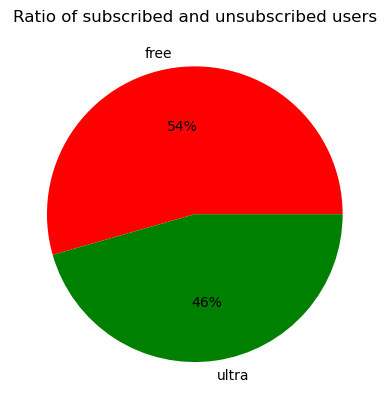

In [19]:
subscription_type_count.plot(
    kind= 'pie',
    title='Ratio of subscribed and unsubscribed users',
    autopct= '%.0f%%',
    ylabel='',
    colors= ['red', 'green']
)

plt.show()

### Task 3.5 Age histogram

In [20]:
# Calculation of the number of bins as the difference between the max and min ages

n_bins = df_users_go['age'].max() - df_users_go['age'].min()

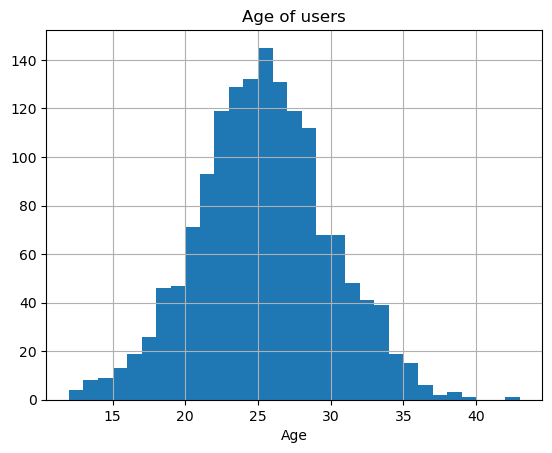

In [21]:
# Histogram

df_users_go['age'].hist(bins=n_bins)
plt.title('Age of users')
plt.xlabel('Age')

plt.show()

### Task 3.6 Minor users

In [22]:
users_under_18_ratio = (df_users_go[df_users_go['age'] < 18].shape[0] / df_users_go.shape[0]) * 100

# Rounding and forced casting to int
users_under_18_ratio = int(round(users_under_18_ratio))

print(f'The share of underage scooter users is {users_under_18_ratio}%.')

The share of underage scooter users is 5%.


### Task 3.7 Characteristics of trip duration

In [23]:
duration_mean = int(round(df_rides_go['duration'].mean()))
duration_std = int(round(df_rides_go['duration'].std()))

duration_pct25 = int(df_rides_go['duration'].quantile(0.25))
duration_pct75 = int(df_rides_go['duration'].quantile(0.75))

print(f'The average trip duration is {duration_mean} minutes with a standard deviation of {duration_std}. The majority of trips take between {duration_pct25} and {duration_pct75} минут.')

The average trip duration is 18 minutes with a standard deviation of 6. The majority of trips take between 14 and 22 минут.


## Task 4. Data consolidation
Combining all data into one data frame.

### Task 4.1 Joining the users and trips table

In [24]:
df = df_users_go.merge(df_rides_go, on='user_id', how='left')

### Task 4.2 Attaching subscription information

In [25]:
df = df.merge(df_subscriptions_go, on='subscription_type', how='left')

### Task 4.3. Dimensions of the combined dataframe

In [26]:
# Output the first lines of the dataframe
display(df.head())

# Display the number of rows and columns in the merged dataframe
n_rows, n_cols = df.shape
print(f'In the received data frame {n_rows} rows and {n_cols} columns.')

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,26,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,16,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,19,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26,2021-08-28,8,6,0,199


In the received data frame 18068 rows and 12 columns.


### Task 4.4 Separate dataframes for users with and without subscriptions

In [27]:
# Users with subscriptions

df_ultra = df[df['subscription_type'] == 'ultra']

In [28]:
# Users without subscriptions

df_free = df[df['subscription_type'] == 'free']

In [29]:
# Check

print(f"Размер df_ultra: {df_ultra.shape}")
print(f"Размер df_free: {df_free.shape}")

Размер df_ultra: (6500, 12)
Размер df_free: (11568, 12)


### Task 4.5 Histogram of trip durations for both groups

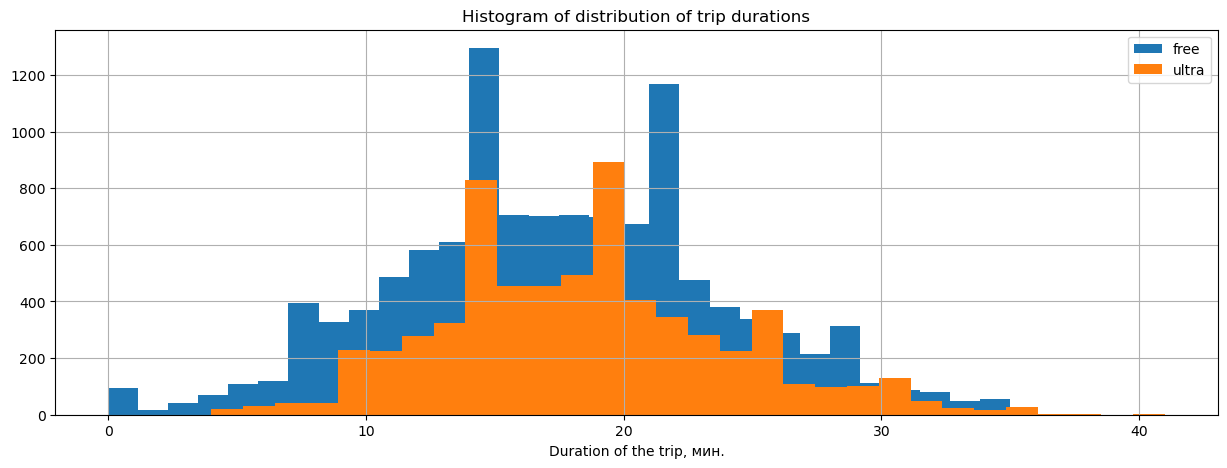

Average trip duration for non-subscribers 17 minutes, and for users with a subscription 19 мин


In [30]:
# Trip duration histogram for users with and without a subscription

plt.figure(figsize=(15, 5))
df_free['duration'].hist(bins=30, label='free')
df_ultra['duration'].hist(bins=30, label='ultra')

plt.xlabel('Duration of the trip, мин.')
plt.title('Histogram of distribution of trip durations')
plt.legend()
plt.show()

# Calculate and display the average trip duration for users with and without a subscription

mean_duration_free = round(df_free['duration'].mean())
mean_duration_ultra = round(df_ultra['duration'].mean())
print(f'Average trip duration for non-subscribers {mean_duration_free} minutes, and for users with a subscription {mean_duration_ultra} мин')

## Task 5. Calculating Revenue
Calculating Revenue

### Task 5.1 Data grouped by the required columns

In [31]:
# Grouping by the desired columns

df_gp = df.groupby(
    ['user_id', 'name', 'subscription_type', 'month'], 
    as_index=False)

### Task 5.2 Calculating aggregated metrics

In [32]:
# Temporarily adjust the keys of the original df_gp object to remove an internal conflict in pandas

df_gp.keys = ['user_id', 'name', 'month']

# Call the named aggregation strictly according to the text of the technical specifications
df_agg = df_gp.agg(
    total_distance=('distance', 'sum'),
    total_duration=('duration', 'sum'),
    rides_count=('duration', 'count'),
    subscription_type=('subscription_type', 'first'),
    minute_price=('minute_price', 'first'),
    start_ride_price=('start_ride_price', 'first'),
    subscription_fee=('subscription_fee', 'first')
)

In [33]:
# Check

display(df_agg.head())

,user_id,name,month,total_distance,total_duration,rides_count,subscription_type,minute_price,start_ride_price,subscription_fee
0,1,Кира,1,7027.511294,42,2,ultra,6,0,199
1,1,Кира,4,754.159807,6,1,ultra,6,0,199
2,1,Кира,8,6723.470560,45,2,ultra,6,0,199
3,1,Кира,10,5809.911100,32,2,ultra,6,0,199
4,1,Кира,11,7003.499363,53,3,ultra,6,0,199


### Task 5.3 Function for calculating revenue

In [34]:
def calculate_monthly_revenue(row):
    # Extract the required metrics and financial parameters from the string
    start_ride_price = row['start_ride_price']
    rides_count = row['rides_count']
    minute_price = row['minute_price']
    total_duration = row['total_duration']
    subscription_fee = row['subscription_fee']
    
    # Calculate the total monthly revenue using the formula
    monthly_revenue = start_ride_price * rides_count + minute_price * total_duration + subscription_fee
    
    return monthly_revenue

### Task 5.4 Creating a column with monthly revenue per user

In [35]:
# Creating a column with monthly revenue per user

df_agg['monthly_revenue'] = df_agg.apply(calculate_monthly_revenue, axis=1)

# Display the first lines to check the revenue calculation results

display(df_agg[['user_id', 'month', 'rides_count', 'total_duration', 'monthly_revenue']].head())

,user_id,month,rides_count,total_duration,monthly_revenue
0,1,1,2,42,451
1,1,4,1,6,235
2,1,8,2,45,469
3,1,10,2,32,391
4,1,11,3,53,517


### Task 5.5 Finding the user with the maximum revenue

In [37]:
# If df_agg doesn't yet contain names, add them from the users table

if 'name' not in df_agg.columns:
    df_agg = df_agg.merge(df_users_go[['user_id', 'name']], on='user_id', how='left')

In [38]:
# Find the user_id of the user with the maximum total revenue for the entire year

max_revenue_user_id = df_agg.groupby('user_id')['monthly_revenue'].sum().idxmax()

In [39]:
# Filter df_agg by this user and select only the required columns

top_user_data = df_agg[df_agg['user_id'] == max_revenue_user_id][
    ['user_id', 'name', 'month', 'rides_count', 'monthly_revenue']
]

In [40]:
# Display the results

display(top_user_data)

,user_id,name,month,rides_count,monthly_revenue
8877,1236,Александр,1,2,228
8878,1236,Александр,2,3,614
8879,1236,Александр,3,5,762
8880,1236,Александр,4,1,202
8881,1236,Александр,5,3,574
8882,1236,Александр,6,1,282
8883,1236,Александр,7,1,290
8884,1236,Александр,8,2,452
8885,1236,Александр,9,1,122
8886,1236,Александр,10,3,430


## Task 6. Testing hypotheses

### Task 6.1 Importing the SciPy library

In [41]:
import scipy.stats as st

### Task 6.2 Auxiliary function for interpreting results

In [42]:
def print_stattest_results(p_value:float, alpha:float = 0.05):
    # Checking whether the p-value is less than the significance level alpha
    if p_value < alpha:
        print(f'The resulting value p_value={p_value} below critical level alpha={alpha}. We accept the alternative hypothesis.')
    else:
        print(f'The resulting value p_value={p_value} above the critical level alpha={alpha}. The null hypothesis cannot be rejected.')

print_stattest_results(p_value=0.0001)
print_stattest_results(p_value=0.1)

The resulting value p_value=0.0001 below critical level alpha=0.05. We accept the alternative hypothesis.
The resulting value p_value=0.1 above the critical level alpha=0.05. The null hypothesis cannot be rejected.


### Task 6.3 Duration for users with and without a subscription

In [43]:
ultra_duration = df_ultra['duration']
free_duration = df_free['duration']

results = st.ttest_ind(ultra_duration, free_duration, alternative='greater') 
p_value = results.pvalue
print_stattest_results(p_value)
ultra_mean_duration = round(df_ultra['duration'].mean(), 2)
free_mean_duration = round(df_free['duration'].mean(), 2)

print(f'Average trip duration for the tariff Ultra {ultra_mean_duration}')
print(f'Average trip duration for the tariff Free {free_mean_duration}')

The resulting value p_value=3.1600689435611813e-35 below critical level alpha=0.05. We accept the alternative hypothesis.
Average trip duration for the tariff Ultra 18.55
Average trip duration for the tariff Free 17.39


### Problem 6.4 Travel duration: greater or less than the critical value

In [44]:
null_hypothesis = 3130
ultra_distance = df_ultra['distance']

results = st.ttest_1samp(ultra_distance, null_hypothesis, alternative='greater')
p_value = results.pvalue
print_stattest_results(p_value)

The resulting value p_value=0.9195368847849785 above the critical level alpha=0.05. The null hypothesis cannot be rejected.


### Task 6.5 Profit from users with and without subscription

In [45]:
revenue_ultra = df_agg[df_agg['subscription_type'] == 'ultra']['monthly_revenue']
revenue_free = df_agg[df_agg['subscription_type'] == 'free']['monthly_revenue']

results = st.ttest_ind(revenue_ultra, revenue_free, alternative='greater')
p_value = results.pvalue
print_stattest_results(p_value)

mean_revenue_ultra = round(revenue_ultra.mean())
mean_revenue_free = round(revenue_free.mean())

print(f'Average trip duration for the tariff Ultra {mean_revenue_ultra} RUB')
print(f'Average trip duration for the tariff Free {mean_revenue_free} RUB')

The resulting value p_value=1.7274069878387966e-37 below critical level alpha=0.05. We accept the alternative hypothesis.
Average trip duration for the tariff Ultra 359 RUB
Average trip duration for the tariff Free 322 RUB


## Task 7. Distributions

### Task 7.1 Calculation of sample mean and standard deviation

In [46]:
# The average value
mu = df_ultra['duration'].mean()

# The standard deviation
sigma = df_ultra['duration'].std()

# Set a target time
target_time = 30

# Conclusion
print(f'Average trip duration {round(mu, 1)}, the standard deviation {round(sigma, 1)}.')

Average trip duration 18.5, the standard deviation 5.6.


### Task 7.2 Calculating the value of the distribution function at a point (CDF)

In [47]:
# Calculate the probability that a random variable will be less than or equal to the specified value

duration_norm_dist  = st.norm(mu, sigma)
prob = round(1 - duration_norm_dist.cdf(target_time), 3) 

print(f'The trip is likely to take more than 30 minutes {prob}')

The trip is likely to take more than 30 minutes 0.02


### Task 7.3 Probability for an Interval (CDF)Task

In [48]:
# The boundaries of the interval

low = 20
high = 30

# Calculate the probability of falling into the interval

prob_interval = round(duration_norm_dist.cdf(high) - duration_norm_dist.cdf(low), 3)

# Results

print(f'The probability that a user will take a trip lasting between {low} and {high} minutes:{prob_interval}')

The probability that a user will take a trip lasting between 20 and 30 minutes:0.377


### Task 7.4 Determining the critical travel distance (PPF)

In [49]:
# The average value

mu = df['distance'].mean()

# The standard deviation

sigma = df['distance'].std()

# Probability for which we want to find the value (90% of cases)

target_prob = 0.90

# Create a normal distribution object

distance_norm = st.norm(mu, sigma)

# Calculate the critical distance for a given percentile of trips

critical_distance = distance_norm.ppf(target_prob)

print(f'{100 * target_prob} of trips have a distance below the critical value {critical_distance:.2f} М.')

90.0 of trips have a distance below the critical value 4501.94 М.
